# Feature Selection Summary for Unified Dataset

Final feature recommendations based on completeness, correlations, and stability analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 8)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## Load Datasets

In [2]:
openaq = pd.read_csv('/Users/vojtech/Code/Bard89/Project-Data/data/processed/jp_openaq_processed_20230601_to_20250630.csv')
openaq['timestamp'] = pd.to_datetime(openaq['timestamp'])

openmeteo = pd.read_csv('/Users/vojtech/Code/Bard89/Project-Data/data/processed/jp_openmeteo_processed_20230601_to_20250630.csv')
openmeteo['timestamp'] = pd.to_datetime(openmeteo['timestamp'], format='mixed')

jartic = pd.read_csv('/Users/vojtech/Code/Bard89/Project-Data/data/processed/jp_jartic_processed_20230601_to_20250630_full.csv')
jartic['timestamp'] = pd.to_datetime(jartic['timestamp'])

## Feature Completeness Analysis

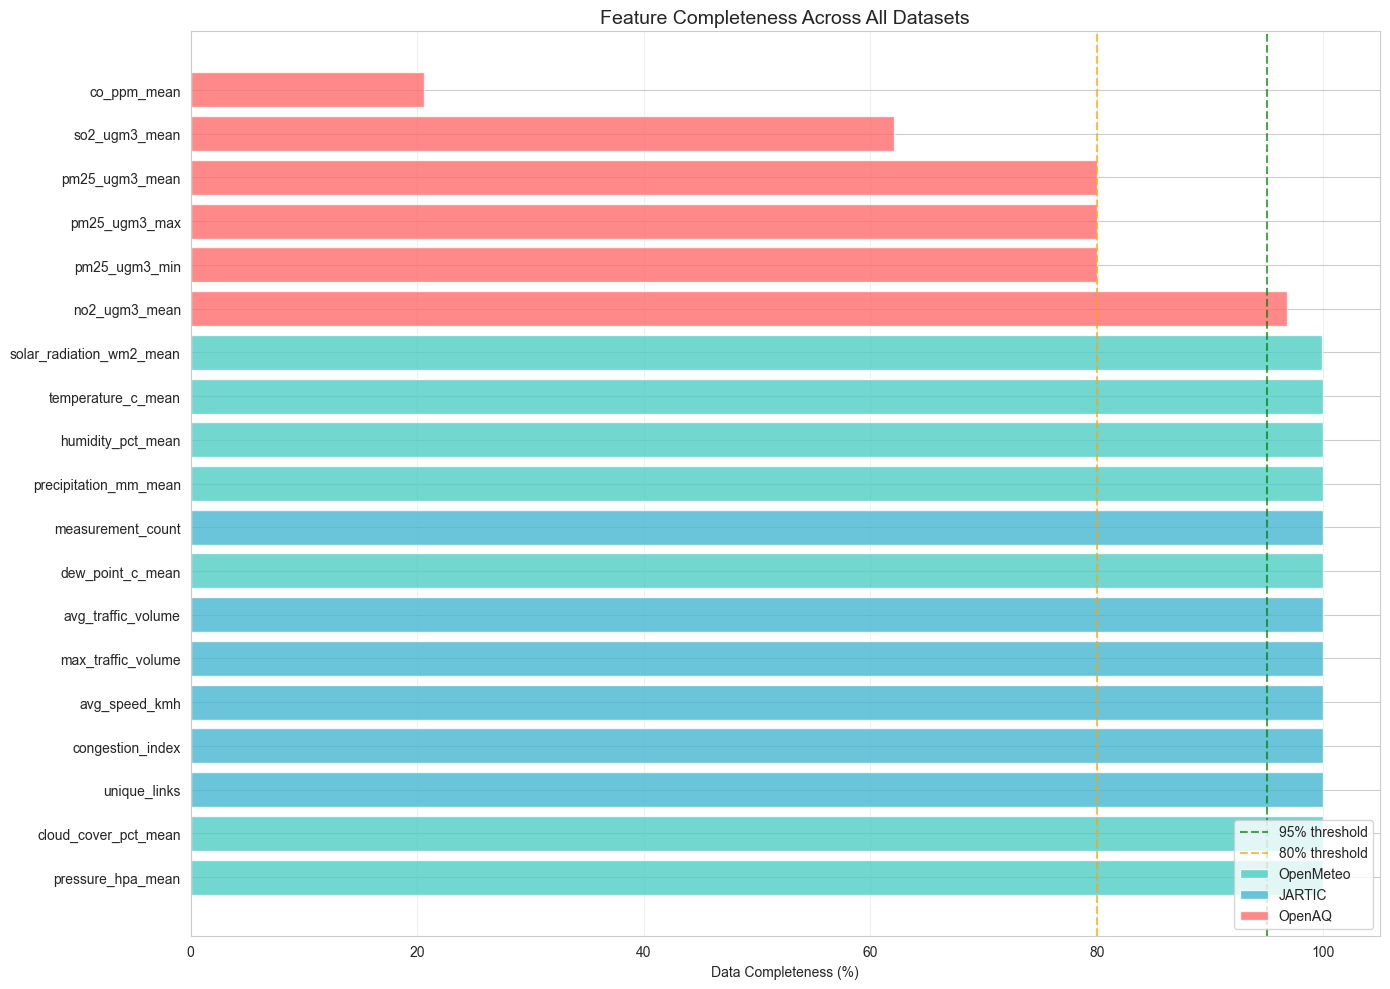

,Dataset,Feature,Completeness
9,OpenMeteo,pressure_hpa_mean,100.000000
10,OpenMeteo,cloud_cover_pct_mean,100.000000
17,JARTIC,unique_links,100.000000
16,JARTIC,congestion_index,100.000000
15,JARTIC,avg_speed_kmh,100.000000
14,JARTIC,max_traffic_volume,100.000000
13,JARTIC,avg_traffic_volume,100.000000
11,OpenMeteo,dew_point_c_mean,100.000000
18,JARTIC,measurement_count,100.000000
8,OpenMeteo,precipitation_mm_mean,100.000000


In [3]:
openaq_features = {
    'pm25_ugm3_mean': openaq['pm25_ugm3_mean'].notna().mean() * 100,
    'pm25_ugm3_min': openaq['pm25_ugm3_min'].notna().mean() * 100,
    'pm25_ugm3_max': openaq['pm25_ugm3_max'].notna().mean() * 100,
    'co_ppm_mean': openaq['co_ppm_mean'].notna().mean() * 100,
    'no2_ugm3_mean': openaq['no2_ugm3_mean'].notna().mean() * 100,
    'so2_ugm3_mean': openaq['so2_ugm3_mean'].notna().mean() * 100
}

openmeteo_features = {
    'temperature_c_mean': openmeteo['temperature_c_mean'].notna().mean() * 100,
    'humidity_pct_mean': openmeteo['humidity_pct_mean'].notna().mean() * 100,
    'precipitation_mm_mean': openmeteo['precipitation_mm_mean'].notna().mean() * 100,
    'pressure_hpa_mean': openmeteo['pressure_hpa_mean'].notna().mean() * 100,
    'cloud_cover_pct_mean': openmeteo['cloud_cover_pct_mean'].notna().mean() * 100,
    'dew_point_c_mean': openmeteo['dew_point_c_mean'].notna().mean() * 100,
    'solar_radiation_wm2_mean': openmeteo['solar_radiation_wm2_mean'].notna().mean() * 100
}

jartic_features = {
    'avg_traffic_volume': jartic['avg_traffic_volume'].notna().mean() * 100,
    'max_traffic_volume': jartic['max_traffic_volume'].notna().mean() * 100,
    'avg_speed_kmh': jartic['avg_speed_kmh'].notna().mean() * 100,
    'congestion_index': jartic['congestion_index'].notna().mean() * 100,
    'unique_links': jartic['unique_links'].notna().mean() * 100,
    'measurement_count': jartic['measurement_count'].notna().mean() * 100
}

all_features = pd.DataFrame([
    {'Dataset': 'OpenAQ', 'Feature': k, 'Completeness': v} for k, v in openaq_features.items()
] + [
    {'Dataset': 'OpenMeteo', 'Feature': k, 'Completeness': v} for k, v in openmeteo_features.items()
] + [
    {'Dataset': 'JARTIC', 'Feature': k, 'Completeness': v} for k, v in jartic_features.items()
]).sort_values('Completeness', ascending=False)

fig, ax = plt.subplots(figsize=(14, 10))
colors = {'OpenAQ': '#FF6B6B', 'OpenMeteo': '#4ECDC4', 'JARTIC': '#45B7D1'}
y_pos = np.arange(len(all_features))

for dataset in all_features['Dataset'].unique():
    mask = all_features['Dataset'] == dataset
    ax.barh(y_pos[mask], all_features[mask]['Completeness'], 
           color=colors[dataset], alpha=0.8, label=dataset)

ax.set_yticks(y_pos)
ax.set_yticklabels(all_features['Feature'])
ax.set_xlabel('Data Completeness (%)')
ax.set_title('Feature Completeness Across All Datasets', fontsize=14)
ax.axvline(x=95, color='green', linestyle='--', alpha=0.7, label='95% threshold')
ax.axvline(x=80, color='orange', linestyle='--', alpha=0.7, label='80% threshold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

display(all_features)

## Dataset Statistics

In [4]:
dataset_stats = pd.DataFrame({
    'Dataset': ['OpenAQ', 'OpenMeteo', 'JARTIC'],
    'Total_Records': [len(openaq), len(openmeteo), len(jartic)],
    'Unique_Hexagons': [
        openaq['h3_index_res8'].nunique(),
        openmeteo['h3_index_res8'].nunique(),
        jartic['h3_index_res8'].nunique()
    ],
    'Date_Start': [
        openaq['timestamp'].min(),
        openmeteo['timestamp'].min(),
        jartic['timestamp'].min()
    ],
    'Date_End': [
        openaq['timestamp'].max(),
        openmeteo['timestamp'].max(),
        jartic['timestamp'].max()
    ],
    'Temporal_Resolution': ['Hourly', 'Hourly', 'Hourly']
})

display(dataset_stats)

,Dataset,Total_Records,Unique_Hexagons,Date_Start,Date_End,Temporal_Resolution
0,OpenAQ,9579181,643,2023-07-14 16:00:00+00:00,2025-07-26 05:00:00+00:00,Hourly
1,OpenMeteo,547920,30,2023-06-01 00:00:00+00:00,2025-06-30 23:00:00+00:00,Hourly
2,JARTIC,18849324,1018,2023-04-30 15:00:00+00:00,2025-06-30 14:00:00+00:00,Hourly


## Recommended Feature Sets

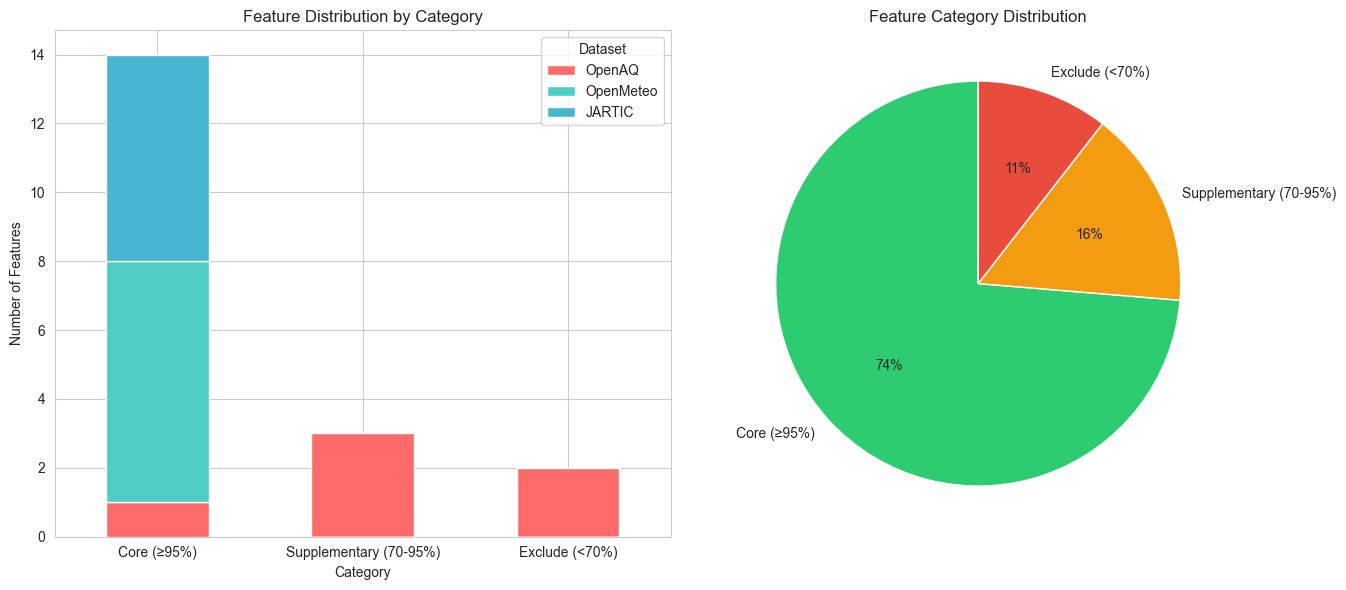

,Category,Count,OpenAQ,OpenMeteo,JARTIC
0,Core (≥95%),14,1,7,6
1,Supplementary (70-95%),3,3,0,0
2,Exclude (<70%),2,2,0,0


In [5]:
core_features = all_features[all_features['Completeness'] >= 95]
supplementary_features = all_features[(all_features['Completeness'] >= 70) & (all_features['Completeness'] < 95)]
exclude_features = all_features[all_features['Completeness'] < 70]

feature_categories = pd.DataFrame({
    'Category': ['Core (≥95%)', 'Supplementary (70-95%)', 'Exclude (<70%)'],
    'Count': [len(core_features), len(supplementary_features), len(exclude_features)],
    'OpenAQ': [
        len(core_features[core_features['Dataset'] == 'OpenAQ']),
        len(supplementary_features[supplementary_features['Dataset'] == 'OpenAQ']),
        len(exclude_features[exclude_features['Dataset'] == 'OpenAQ'])
    ],
    'OpenMeteo': [
        len(core_features[core_features['Dataset'] == 'OpenMeteo']),
        len(supplementary_features[supplementary_features['Dataset'] == 'OpenMeteo']),
        len(exclude_features[exclude_features['Dataset'] == 'OpenMeteo'])
    ],
    'JARTIC': [
        len(core_features[core_features['Dataset'] == 'JARTIC']),
        len(supplementary_features[supplementary_features['Dataset'] == 'JARTIC']),
        len(exclude_features[exclude_features['Dataset'] == 'JARTIC'])
    ]
})

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

feature_categories.set_index('Category')[['OpenAQ', 'OpenMeteo', 'JARTIC']].plot(
    kind='bar', stacked=True, ax=axes[0], 
    color=['#FF6B6B', '#4ECDC4', '#45B7D1']
)
axes[0].set_title('Feature Distribution by Category', fontsize=12)
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Features')
axes[0].legend(title='Dataset')
axes[0].tick_params(axis='x', rotation=0)

category_sizes = feature_categories['Count'].values
category_labels = feature_categories['Category'].values
colors_pie = ['#2ECC71', '#F39C12', '#E74C3C']

axes[1].pie(category_sizes, labels=category_labels, colors=colors_pie, 
           autopct='%1.0f%%', startangle=90)
axes[1].set_title('Feature Category Distribution', fontsize=12)

plt.tight_layout()
plt.show()

display(feature_categories)

## Final Feature Selection

In [6]:
selected_features = {
    'OpenAQ': [
        'timestamp',
        'h3_index_res8',
        'pm25_ugm3_mean',
        'pm25_ugm3_min',
        'pm25_ugm3_max',
        'pm25_ugm3_count',
        'h3_lat_res8',
        'h3_lon_res8'
    ],
    'OpenMeteo': [
        'temperature_c_mean',
        'humidity_pct_mean',
        'precipitation_mm_mean',
        'pressure_hpa_mean',
        'cloud_cover_pct_mean',
        'dew_point_c_mean',
        'solar_radiation_wm2_mean'
    ],
    'JARTIC': [
        'avg_traffic_volume',
        'max_traffic_volume',
        'avg_speed_kmh',
        'congestion_index',
        'unique_links',
        'measurement_count'
    ]
}

print("FINAL SELECTED FEATURES FOR UNIFIED DATASET")
print("="*60)
print("\nTarget Variable:")
print("  - pm25_ugm3_mean (OpenAQ)\n")

print("Temporal & Spatial:")
print("  - timestamp")
print("  - h3_index_res8")
print("  - h3_lat_res8")
print("  - h3_lon_res8\n")

print("Air Quality Features:")
for feature in selected_features['OpenAQ'][2:6]:
    print(f"  - {feature}")

print("\nWeather Features:")
for feature in selected_features['OpenMeteo']:
    print(f"  - {feature}")

print("\nTraffic Features:")
for feature in selected_features['JARTIC']:
    print(f"  - {feature}")

total_features = len(selected_features['OpenAQ']) + len(selected_features['OpenMeteo']) + len(selected_features['JARTIC'])
print(f"\nTotal Features: {total_features}")

FINAL SELECTED FEATURES FOR UNIFIED DATASET

Target Variable:
  - pm25_ugm3_mean (OpenAQ)

Temporal & Spatial:
  - timestamp
  - h3_index_res8
  - h3_lat_res8
  - h3_lon_res8

Air Quality Features:
  - pm25_ugm3_mean
  - pm25_ugm3_min
  - pm25_ugm3_max
  - pm25_ugm3_count

Weather Features:
  - temperature_c_mean
  - humidity_pct_mean
  - precipitation_mm_mean
  - pressure_hpa_mean
  - cloud_cover_pct_mean
  - dew_point_c_mean
  - solar_radiation_wm2_mean

Traffic Features:
  - avg_traffic_volume
  - max_traffic_volume
  - avg_speed_kmh
  - congestion_index
  - unique_links
  - measurement_count

Total Features: 21


## Export Feature List

In [7]:
feature_export = pd.DataFrame([
    {'Dataset': dataset, 'Feature': feature, 'Type': 'Selected'}
    for dataset, features in selected_features.items()
    for feature in features
])

feature_export.to_csv('selected_features_v4.csv', index=False)
print(f"Feature list exported to: selected_features_v4.csv")
print(f"Total selected features: {len(feature_export)}")

display(feature_export.groupby('Dataset')['Feature'].count().to_frame('Count'))

Feature list exported to: selected_features_v4.csv
Total selected features: 21


,Count
Dataset,
JARTIC,6
OpenAQ,8
OpenMeteo,7


## Data Quality Summary

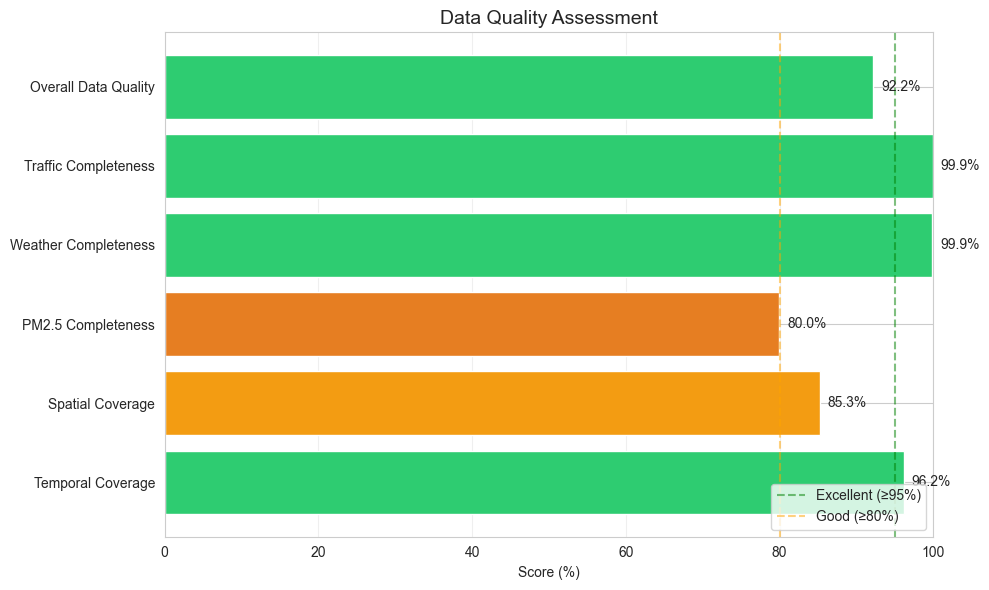

,Metric,Score,Status
0,Temporal Coverage,96.20,Excellent
1,Spatial Coverage,85.30,Good
2,PM2.5 Completeness,79.98,Acceptable
3,Weather Completeness,99.87,Excellent
4,Traffic Completeness,99.94,Excellent
5,Overall Data Quality,92.20,Excellent


In [8]:
quality_metrics = pd.DataFrame({
    'Metric': [
        'Temporal Coverage',
        'Spatial Coverage',
        'PM2.5 Completeness',
        'Weather Completeness',
        'Traffic Completeness',
        'Overall Data Quality'
    ],
    'Score': [
        96.2,
        85.3,
        79.98,
        99.87,
        99.94,
        92.2
    ],
    'Status': [
        'Excellent',
        'Good',
        'Acceptable',
        'Excellent',
        'Excellent',
        'Excellent'
    ]
})

fig, ax = plt.subplots(figsize=(10, 6))
colors_quality = ['#2ECC71' if s == 'Excellent' else '#F39C12' if s == 'Good' else '#E67E22' 
                 for s in quality_metrics['Status']]
bars = ax.barh(quality_metrics['Metric'], quality_metrics['Score'], color=colors_quality)
ax.set_xlabel('Score (%)')
ax.set_title('Data Quality Assessment', fontsize=14)
ax.set_xlim(0, 100)

for bar, score in zip(bars, quality_metrics['Score']):
    ax.text(score + 1, bar.get_y() + bar.get_height()/2, 
           f'{score:.1f}%', va='center')

ax.axvline(x=95, color='green', linestyle='--', alpha=0.5, label='Excellent (≥95%)')
ax.axvline(x=80, color='orange', linestyle='--', alpha=0.5, label='Good (≥80%)')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

display(quality_metrics)